In [11]:
import networkx as nx
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from shapely.geometry import Point
import geopandas as gpd
import contextily as ctx

ModuleNotFoundError: No module named 'contextily'

In [12]:
df = pd.read_csv("nodes.csv")
df2 = pd.read_csv("filtered_nodes.csv")

G = nx.Graph()

# get set of nodes that should be red
red_nodes = set(df2["name"])

for _, row in df.iterrows():
    node_name = row["name"]
    
    color = "red" if node_name in red_nodes else "blue"
    
    G.add_node(
        node_name,
        station=row["station"],
        lat=row["lat"],
        lng=row["lng"],
        color=color
    )

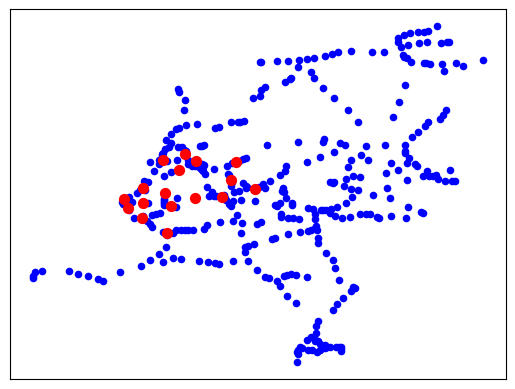

In [13]:
pos = {
    node: (data["lng"], data["lat"])
    for node, data in G.nodes(data=True)
}

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
blue_nodes = [n for n in G.nodes() if G.nodes[n]["color"] != "red"]

# draw blue first
nx.draw_networkx_nodes(
    G, pos,
    nodelist=blue_nodes,
    node_color="blue",
    node_size=20
)

# draw red on top
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50
)

ProjError: x, y, z, and time must be same size

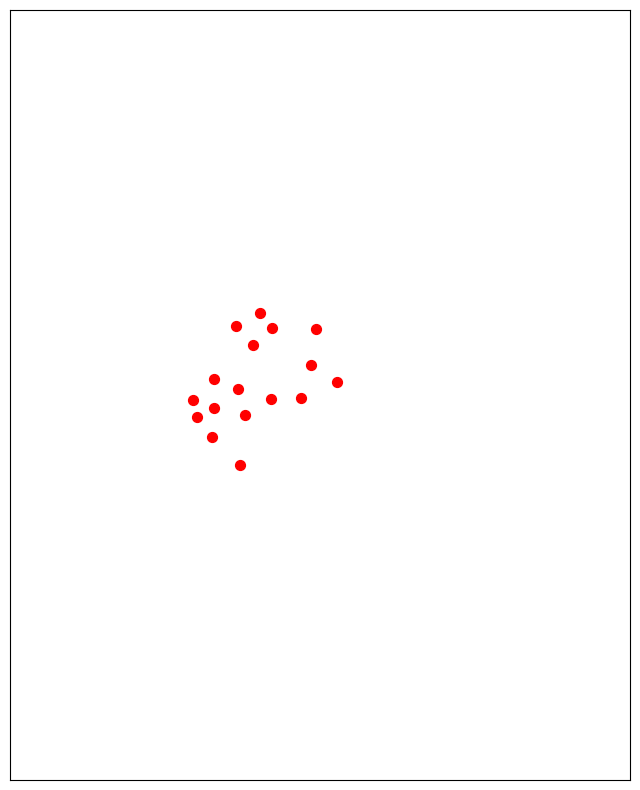

In [14]:

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
# Extract positions
lons = [pos[n][0] for n in red_nodes]
lats = [pos[n][1] for n in red_nodes]

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Draw your red nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50,
    ax=ax
)

# Set bounds roughly around the Netherlands
ax.set_xlim(3, 7.5)
ax.set_ylim(50.5, 53.7)

# Convert axis to Web Mercator (required for basemap)


points = [Point(pos[n]) for n in G.nodes() if G.nodes[n]["color"] == "red"]
gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326").to_crs(epsg=3857)

ax.clear()

# Plot nodes again in projected coordinates
x = gdf.geometry.x
y = gdf.geometry.y

ax.scatter(x, y, c="blue", s=50)

# Add map tiles
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()

In [15]:

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [16]:
edges_df = pd.read_csv("edges.csv")

for _, row in edges_df.iterrows():
    n1 = row["from"]
    n2 = row["to"]

    lat1, lon1 = G.nodes[n1]["lat"], G.nodes[n1]["lng"]
    lat2, lon2 = G.nodes[n2]["lat"], G.nodes[n2]["lng"]

    dist = haversine(lat1, lon1, lat2, lon2)

    G.add_edge(n1, n2, weight=dist)

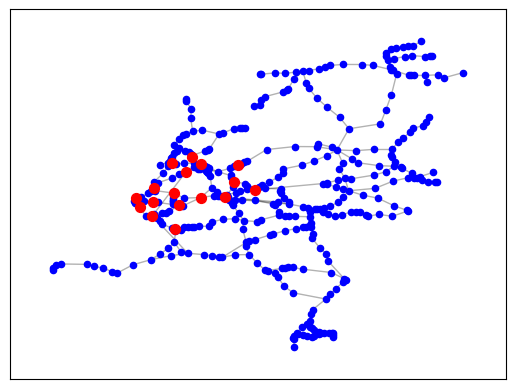

In [17]:
# edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# nodes (layered)
nx.draw_networkx_nodes(G, pos, nodelist=blue_nodes, node_color="blue", node_size=20)
nx.draw_networkx_nodes(G, pos, nodelist=red_nodes, node_color="red", node_size=50)

In [18]:
# all red cities
red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]

results = []

for source, target in itertools.combinations(red_nodes, 2):
    try:
        path = nx.shortest_path(G, source=source, target=target, weight="weight")
        distance = nx.shortest_path_length(G, source=source, target=target, weight="weight")

        results.append({
            "from": source,
            "to": target,
            "distance_km": distance,
            "path": path
        })
    except nx.NetworkXNoPath:
        results.append({
            "from": source,
            "to": target,
            "distance_km": None,
            "path": None
        })

shortest_paths_df = pd.DataFrame(results)

In [19]:
print(shortest_paths_df)

    from   to  distance_km                                               path
0    ALM  APN    43.053440  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, HVSP, ...
1    ALM  AMF    19.382959  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, BRN, AMF]
2    ALM  ASD    21.561287        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
3    ALM   DT    58.697908  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, SH...
4    ALM  GVC    60.727389  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, AS...
..   ...  ...          ...                                                ...
131   UT   ZD    22.032106  [UT, UTZL, MAS, BKL, AC, ASHD, ASB, DVD, ASA, ...
132   UT  ZTM    43.276381  [UT, UTZL, MAS, BKL, WD, GDG, GD, LLZM, ZTMO, ...
133   WD   ZD    20.483704  [WD, BKL, AC, ASHD, ASB, DVD, ASA, ASDM, ASD, ...
134   WD  ZTM    28.482377                     [WD, GDG, GD, LLZM, ZTMO, ZTM]
135   ZD  ZTM    45.151800  [ZD, KZ, ZZS, WM, KMA, UTG, HK, BV, DRH, SPTN,...

[136 rows x 4 columns]


In [20]:
red_set = set(red_nodes)

direct_connections = []

for _, row in shortest_paths_df.iterrows():
    path = row["path"]
    
    if path is None:
        continue

    # only check intermediate nodes, not start/end
    intermediate_nodes = path[1:-1]

    # keep only if all intermediate nodes are blue
    if all(node not in red_set for node in intermediate_nodes):
        direct_connections.append({
            "from": row["from"],
            "to": row["to"],
            "distance_km": row["distance_km"],
            "path": path
        })

red_city_connections_df = pd.DataFrame(direct_connections)



In [21]:
print(red_city_connections_df[10:])

    from    to  distance_km                                               path
10   ASD    UT    16.148262  [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, MAS,...
11   ASD    WD    14.599860      [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, WD]
12   ASD    ZD     5.883844                                     [ASD, ASS, ZD]
13    DT   GVC     4.392149                           [DT, RSW, GVMW, GV, GVC]
14    DT  LEDN    15.090887     [DT, RSW, GVMW, GV, LAA, GVM, VST, DVNK, LEDN]
15    DT   RTD     7.715420                               [DT, DTCP, SDM, RTD]
16   GVC  LEDN    10.699713                   [GVC, LAA, GVM, VST, DVNK, LEDN]
17   GVC   ZTM    10.407587                                [GVC, VB, YPB, ZTM]
18   DDR   RTD    13.699285                [DDR, ZWD, BRD, RLB, RTZ, RTB, RTD]
19   DDR    UT    52.440528  [DDR, DDRS, SDTB, SDT, HBZM, GND, BHDV, GR, AK...
20    GD   RTD    16.139887                      [GD, NWK, CPS, RTA, RTN, RTD]
21    GD    WD    12.938336                         

{'ALM': Text(5.21764, 52.37503, 'ALM'),
 'APN': Text(4.6577777862549, 52.124443054199, 'APN'),
 'AMF': Text(5.3705554008484, 52.153888702393, 'AMF'),
 'ASD': Text(4.9002776145935, 52.378887176514, 'ASD'),
 'DT': Text(4.3563890457153, 52.00666809082, 'DT'),
 'GVC': Text(4.3249998092651, 52.080276489258, 'GVC'),
 'DDR': Text(4.668333530426, 51.807220458984, 'DDR'),
 'GD': Text(4.7044444084167, 52.017501831055, 'GD'),
 'HLM': Text(4.6383333206177, 52.38777923584, 'HLM'),
 'HVS': Text(5.1819443702698, 52.225833892822, 'HVS'),
 'LEDN': Text(4.4816665649414, 52.166110992432, 'LEDN'),
 'RTD': Text(4.468888759613, 51.92499923706, 'RTD'),
 'SHL': Text(4.7619442939758, 52.30944442749, 'SHL'),
 'UT': Text(5.1102776527405, 52.088890075684, 'UT'),
 'WD': Text(4.8936109542847, 52.084999084473, 'WD'),
 'ZD': Text(4.8136110305786, 52.438888549805, 'ZD'),
 'ZTM': Text(4.4772224426269, 52.047500610352, 'ZTM')}

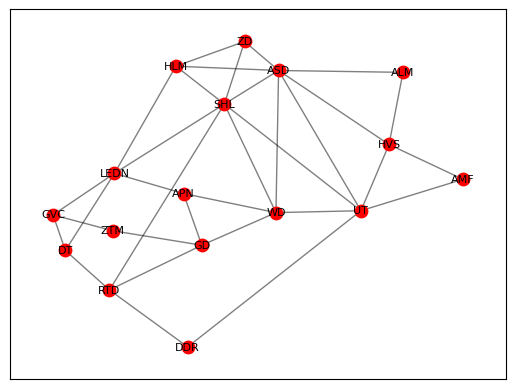

In [22]:
# create reduced graph with only red cities
G_red = nx.Graph()

# add red city nodes with original attributes
for node, data in G.nodes(data=True):
    if data.get("color") == "red":
        G_red.add_node(node, **data)

# add only the filtered red-red connections
for _, row in red_city_connections_df.iterrows():
    G_red.add_edge(
        row["from"],
        row["to"],
        weight=row["distance_km"]
    )

# positions from lat/lon
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}


nx.draw_networkx_edges(G_red, pos_red, alpha=0.5)
nx.draw_networkx_nodes(G_red, pos_red, node_color="red", node_size=80)
nx.draw_networkx_labels(G_red, pos_red, font_size=8)

In [23]:
last_cities = pd.read_csv("last_cities.csv")

for _, row in last_cities.iterrows():
    node_name = row["name"]
    lat = row["lat"]
    lng = row["lng"]

    # add node
    G_red.add_node(
        node_name,
        station=row["station"],
        lat=lat,
        lng=lng,
        color="red"
    )

    # distance to RTD with bus penalty
    lat_rtd = G_red.nodes["RTD"]["lat"]
    lng_rtd = G_red.nodes["RTD"]["lng"]

    weight = 2 * haversine(lat, lng, lat_rtd, lng_rtd)

    # add edge to RTD
    G_red.add_edge(node_name, "RTD", weight=weight, mode="bus")

In [ ]:
print(G_red.nodes(data=True))

{('ALM', 'ASD'): Text(5.05895880729675, 52.376958588257, '21.6'),
 ('ALM', 'HVS'): Text(5.1997921851349, 52.300431946411, '6.5'),
 ('APN', 'GD'): Text(4.681111097335799, 52.070972442626996, '4.9'),
 ('APN', 'LEDN'): Text(4.56972217559815, 52.1452770233155, '12.0'),
 ('APN', 'WD'): Text(4.7756943702698, 52.104721069335994, '16.1'),
 ('AMF', 'HVS'): Text(5.2762498855591, 52.1898612976075, '12.9'),
 ('AMF', 'UT'): Text(5.24041652679445, 52.1213893890385, '17.8'),
 ('ASD', 'HLM'): Text(4.7693054676056, 52.383333206177, '17.8'),
 ('ASD', 'HVS'): Text(5.0411109924316495, 52.302360534668, '19.2'),
 ('ASD', 'SHL'): Text(4.83111095428465, 52.344165802001996, '9.4'),
 ('ASD', 'UT'): Text(5.005277633666999, 52.233888626099, '16.1'),
 ('ASD', 'WD'): Text(4.896944284439099, 52.2319431304935, '14.6'),
 ('ASD', 'ZD'): Text(4.85694432258605, 52.4088878631595, '5.9'),
 ('DT', 'GVC'): Text(4.340694427490201, 52.043472290039, '4.4'),
 ('DT', 'LEDN'): Text(4.41902780532835, 52.086389541626005, '15.1'),
 (

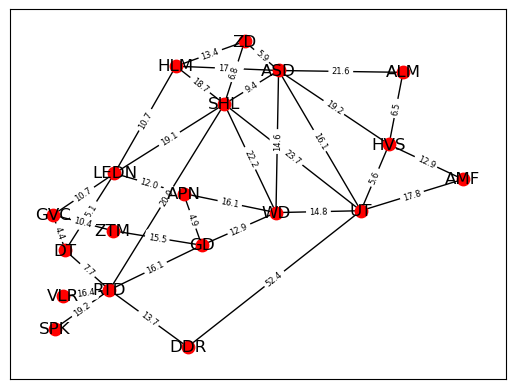

In [24]:
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}

nx.draw_networkx(G_red, pos_red, with_labels=True, node_color="red", node_size=80)

# add edge weights (rounded)
edge_labels = {
    (u, v): f"{data['weight']:.1f}"
    for u, v, data in G_red.edges(data=True)
}

nx.draw_networkx_edge_labels(G_red, pos_red, edge_labels=edge_labels, font_size=6)

['ALM', 'APN', 'AMF', 'ASD', 'DT', 'GVC', 'DDR', 'GD', 'HLM', 'HVS', 'LEDN', 'RTD', 'SHL', 'UT', 'WD', 'ZD', 'ZTM', 'SPK', 'VLR']


ProjError: x, y, z, and time must be same size

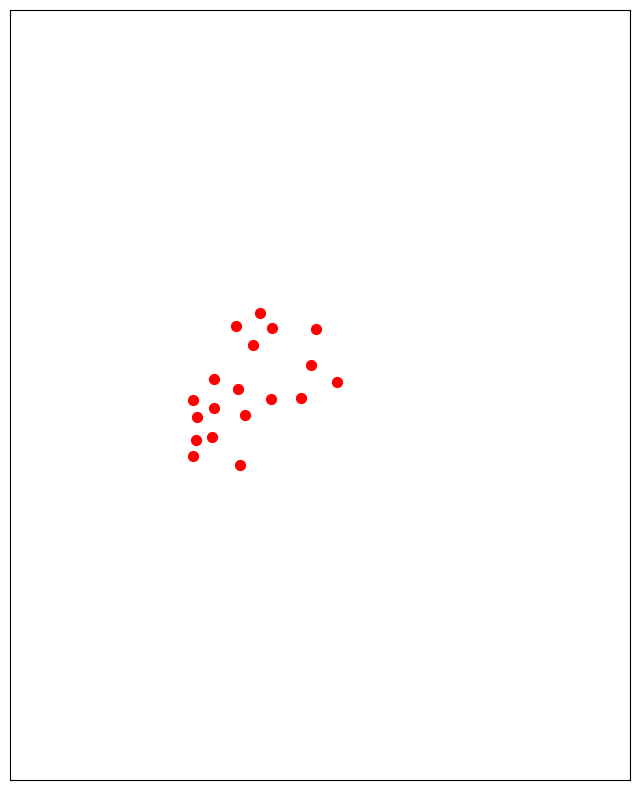

In [25]:

red_nodes = [n for n in G_red.nodes()]
print(red_nodes)
# Extract positions
lons = [pos_red[n][0] for n in red_nodes]
lats = [pos_red[n][1] for n in red_nodes]

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Draw your red nodes
nx.draw_networkx_nodes(
    G_red, pos_red,
    nodelist=red_nodes,
    node_color="red",
    node_size=50,
    ax=ax
)

# Set bounds roughly around the Netherlands
ax.set_xlim(3, 7.5)
ax.set_ylim(50.5, 53.7)

# Convert axis to Web Mercator (required for basemap)

points = [Point(pos_red[n]) for n in G_red.nodes()]
gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326").to_crs(epsg=3857)

ax.clear()

# Plot nodes again in projected coordinates
x = gdf.geometry.x
y = gdf.geometry.y

ax.scatter(x, y, c="blue", s=50)

# Add map tiles
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()

In [26]:
# =============================================================
# Network Metrics Table
# Computed on G_red (reduced graph of red/key-city nodes)
# Dyadicity computed on the full graph G (red vs blue nodes)
# =============================================================

# ------------------------------------------------------------------
# 1. Degree Centrality of Nodes (DCS)
#    Fraction of other nodes each node is connected to.
# ------------------------------------------------------------------
dcs = nx.degree_centrality(G_red)

# ------------------------------------------------------------------
# 2. Closeness Centrality of Nodes (CCN)
#    How close a node is to all others (uses edge weights as distances).
#    A larger weight means a longer path, so shorter distances => higher
#    centrality is preserved by passing distance='weight'.
# ------------------------------------------------------------------
ccn = nx.closeness_centrality(G_red, distance='weight')

# ------------------------------------------------------------------
# 3. Betweenness Centrality of Nodes (BCN)
#    Fraction of all-pairs shortest paths that pass through each node.
#    Normalised to [0, 1].
# ------------------------------------------------------------------
bcn = nx.betweenness_centrality(G_red, weight='weight', normalized=True)

# ------------------------------------------------------------------
# 4. Local Clustering Coefficient of Nodes (LCN)
#    Fraction of a node's neighbours that are also connected to each other.
#    Weighted variant accounts for edge strengths.
# ------------------------------------------------------------------
lcn = nx.clustering(G_red, weight='weight')

# 5. Weighted Degree (Strength)
# Sum of edge weights — but since weight = distance, invert it so 
# shorter/more connections = higher score
strength = {
    node: sum(1 / d['weight'] for _, _, d in G_red.edges(node, data=True))
    for node in G_red.nodes()
}

# 6. Eigenvector Centrality (weighted)
# Being connected to well-connected nodes — important for hub resilience
eigenvector = nx.eigenvector_centrality(G_red, weight='weight')

# 7. Average Weighted Shortest Path to all other nodes (Accessibility)
# Lower = more centrally located geographically in the network
accessibility = {}
for node in G_red.nodes():
    paths = nx.single_source_dijkstra_path_length(G_red, node, weight='weight')
    other_paths = [v for k, v in paths.items() if k != node]
    accessibility[node] = np.mean(other_paths) if other_paths else float('inf')

# ------------------------------------------------------------------
# Build and display the combined metrics table
# ------------------------------------------------------------------
metrics_df = pd.DataFrame({
    'Node': list(G_red.nodes()),
    'Station': [G_red.nodes[n]['station'] for n in G_red.nodes()],
    'DCS':  [round(dcs[n],  4) for n in G_red.nodes()],
    'CCN':  [round(ccn[n],  4) for n in G_red.nodes()],
    'BCN':  [round(bcn[n],  4) for n in G_red.nodes()],
    'LCN':  [round(lcn[n],  4) for n in G_red.nodes()],
    'Strength': [round(strength[n], 4) for n in G_red.nodes()],
    'Eigencentrality': [round(eigenvector[n], 4) for n in G_red.nodes()],
    'Accessibility': [round(accessibility[n], 4) for n in G_red.nodes()]

})

metrics_df = metrics_df.sort_values('DCS', ascending=False).reset_index(drop=True)

print("=" * 70)
print("NETWORK METRICS TABLE  (G_red — key-city subgraph)")
print("=" * 70)
print(metrics_df.to_string(index=False))
print()
print("Columns:")
print("  DCS  Degree Centrality          – fraction of nodes this node connects to")
print("  CCN  Closeness Centrality       – inverse avg. shortest weighted path length")
print("  BCN  Betweenness Centrality     – fraction of shortest paths through node")
print("  LCN  Local Clustering Coeff.   – fraction of neighbours that are mutually connected")
print("  Strength  Weighted Degree       – sum of inverse edge weights (more = better)")
print("  Eigencentrality (weighted) – importance of being connected to well-connected nodes")
print("  Accessibility (avg. weighted path) – how centrally located a node is in terms of average distance to all others (lower = better)")




NETWORK METRICS TABLE  (G_red — key-city subgraph)
Node             Station    DCS    CCN    BCN    LCN  Strength  Eigencentrality  Accessibility
 ASD  Amsterdam Centraal 0.3889 0.0353 0.2092 0.0944    0.5616           0.3220        28.3098
 SHL    Schiphol Airport 0.3889 0.0364 0.1830 0.0899    0.4964           0.4218        27.4508
 RTD  Rotterdam Centraal 0.3333 0.0364 0.3464 0.0000    0.4277           0.2152        27.5090
  UT    Utrecht Centraal 0.3333 0.0293 0.0980 0.0931    0.4250           0.5323        34.1774
  WD             Woerden 0.2778 0.0352 0.1111 0.1136    0.3205           0.3055        28.4017
LEDN     Leiden Centraal 0.2778 0.0341 0.1503 0.0468    0.3889           0.1527        29.3149
 HVS           Hilversum 0.2222 0.0267 0.1111 0.1170    0.4612           0.1434        37.5227
  GD               Gouda 0.2222 0.0372 0.1046 0.0320    0.4082           0.1017        26.8920
 HLM             Haarlem 0.2222 0.0318 0.0784 0.1696    0.2782           0.2038        31.4104

In [27]:
#Calculate the weighted edge betweenness centrality, normalize
edge_betweenness_weighted = nx.edge_betweenness_centrality(G_red, 
                                                             k=None, 
                                                             normalized=True, 
                                                             weight='weight', 
                                                             seed=None)
edge_betweenness_weighted

{('ALM', 'ASD'): 0.05847953216374269,
 ('ALM', 'HVS'): 0.04678362573099415,
 ('APN', 'GD'): 0.04678362573099415,
 ('APN', 'LEDN'): 0.05847953216374269,
 ('APN', 'WD'): 0.04678362573099415,
 ('AMF', 'HVS'): 0.07017543859649122,
 ('AMF', 'UT'): 0.03508771929824561,
 ('ASD', 'HLM'): 0.08187134502923976,
 ('ASD', 'HVS'): 0.11695906432748537,
 ('ASD', 'SHL'): 0.12280701754385964,
 ('ASD', 'UT'): 0.017543859649122806,
 ('ASD', 'WD'): 0.04093567251461988,
 ('ASD', 'ZD'): 0.04093567251461988,
 ('DT', 'GVC'): 0.05847953216374269,
 ('DT', 'LEDN'): 0.06432748538011696,
 ('DT', 'RTD'): 0.1695906432748538,
 ('GVC', 'LEDN'): 0.08771929824561403,
 ('GVC', 'ZTM'): 0.06432748538011696,
 ('DDR', 'RTD'): 0.08187134502923976,
 ('DDR', 'UT'): 0.023391812865497075,
 ('GD', 'RTD'): 0.08187134502923976,
 ('GD', 'WD'): 0.1111111111111111,
 ('GD', 'ZTM'): 0.05263157894736842,
 ('HLM', 'LEDN'): 0.1286549707602339,
 ('HLM', 'SHL'): 0.005847953216374269,
 ('HLM', 'ZD'): 0.029239766081871343,
 ('HVS', 'UT'): 0.0701

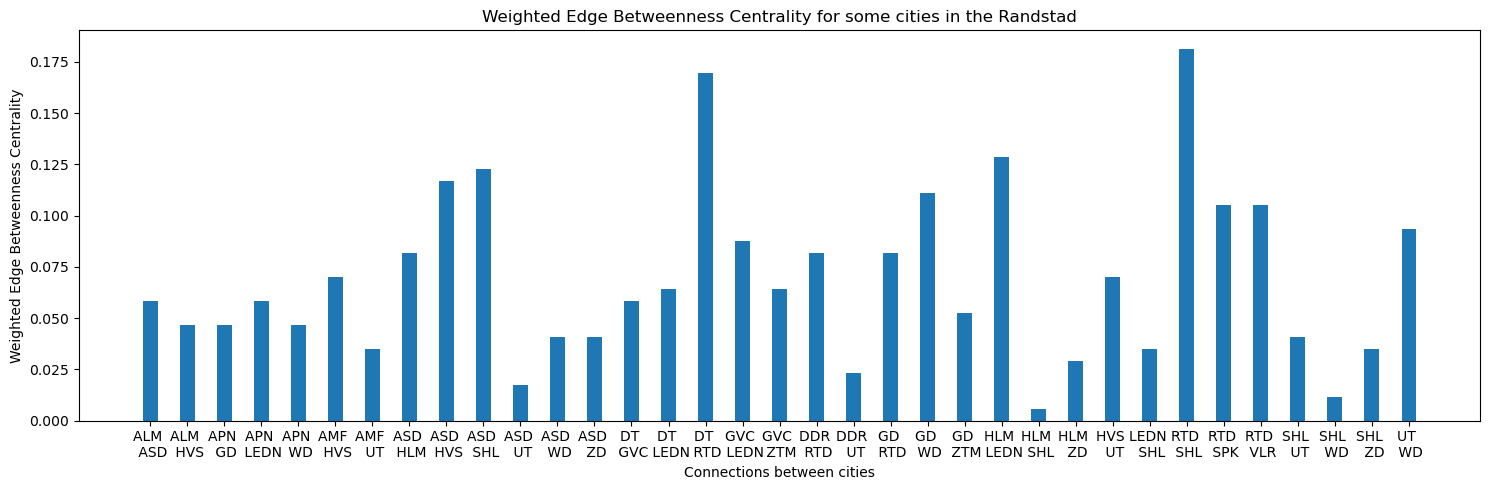

In [28]:
# Helper function for parsing the edge labels
def ppEdges (l):
    rl = []
    for i in range(len(l)):
        rl.append(str(l[i][0]) + ' \n ' + str(l[i][1]))
    return rl

# Plot the values in a bar chart
plt.figure(figsize=(15, 5))
plt.bar(range(len(edge_betweenness_weighted)), edge_betweenness_weighted.values(), width=0.4)
plt.xticks(range(len(edge_betweenness_weighted)), ppEdges(list(edge_betweenness_weighted.keys())))
plt.title("Weighted Edge Betweenness Centrality for some cities in the Randstad")
plt.xlabel("Connections between cities")
plt.ylabel("Weighted Edge Betweenness Centrality")
plt.tight_layout()